Note: Probability Distribution batati hai ki data ke values kaise "phaile" (spread) hue hain — kaunse values zyada common hain, kaunse rare. Normal Distribution (bell-curve) sabse famous hai — bahut saari real-world cheezein (height, exam scores) isi shape mein hoti hain. Business data (jaise spend) hamesha normal nahi hota — aaj yeh check bhi karenge.

1. Data load karo:

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/processed/customer_churn_labeled.csv')

2. Normal Distribution ka concept — synthetic example se pehle samajho:

In [2]:
# Ek perfectly normal distribution generate karo (demo ke liye)
np.random.seed(42)
normal_data = np.random.normal(loc=100, scale=15, size=1000)  # mean=100, std=15

print(f"Mean: {normal_data.mean():.2f}")
print(f"Std: {normal_data.std():.2f}")
print(f"Median: {np.median(normal_data):.2f}")

Mean: 100.29
Std: 14.68
Median: 100.38


Note: Perfect normal distribution mein Mean ≈ Median hota hai (symmetric), aur data "68-95-99.7 rule" follow karta hai — 68% data mean ke ±1 std deviation ke andar, 95% ±2 std, 99.7% ±3 std ke andar.

3. 68-95-99.7 rule verify karo:

In [3]:
mean = normal_data.mean()
std = normal_data.std()

within_1std = ((normal_data > mean - std) & (normal_data < mean + std)).mean() * 100
within_2std = ((normal_data > mean - 2*std) & (normal_data < mean + 2*std)).mean() * 100
within_3std = ((normal_data > mean - 3*std) & (normal_data < mean + 3*std)).mean() * 100

print(f"Within 1 std: {within_1std:.1f}% (expected ~68%)")
print(f"Within 2 std: {within_2std:.1f}% (expected ~95%)")
print(f"Within 3 std: {within_3std:.1f}% (expected ~99.7%)")

Within 1 std: 68.6% (expected ~68%)
Within 2 std: 95.6% (expected ~95%)
Within 3 std: 99.7% (expected ~99.7%)


4. Ab apne real data (Monetary) ka distribution check karo — kya yeh normal hai?

In [4]:
mean_monetary = df['Monetary'].mean()
median_monetary = df['Monetary'].median()

print(f"Mean: {mean_monetary:.2f}, Median: {median_monetary:.2f}")
print(f"Difference: {mean_monetary - median_monetary:.2f}")

Mean: 2954.40, Median: 865.60
Difference: 2088.80


Yaad hai Day 41 se? Tumne dekha tha Mean (₹2892) >> Median (₹854) — yeh confirm karta hai ki Monetary normal distribution nahi hai, balki right-skewed hai (kuch high-value customers tail ko khींch rahe hain).

5. Visual se confirm karna (histogram):

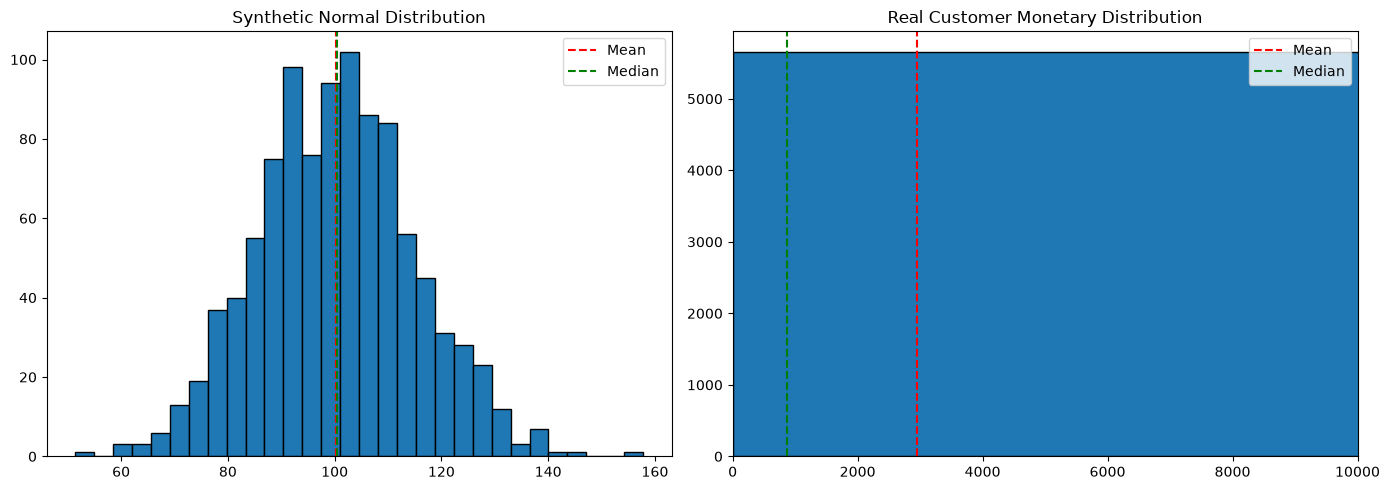

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(normal_data, bins=30, edgecolor='black')
axes[0].axvline(normal_data.mean(), color='red', linestyle='--', label='Mean')
axes[0].axvline(np.median(normal_data), color='green', linestyle='--', label='Median')
axes[0].set_title('Synthetic Normal Distribution')
axes[0].legend()

axes[1].hist(df['Monetary'], bins=50, edgecolor='black')
axes[1].axvline(df['Monetary'].mean(), color='red', linestyle='--', label='Mean')
axes[1].axvline(df['Monetary'].median(), color='green', linestyle='--', label='Median')
axes[1].set_title('Real Customer Monetary Distribution')
axes[1].legend()
axes[1].set_xlim(0, 10000)  # zoom in, kyunki outliers scale ko bahut bada bana dete hain

plt.tight_layout()
plt.show()

Note: Left chart symmetric bell-curve hai (Mean=Median line overlap). Right chart mein saari values left side clustered hain aur ek lambi tail right taraf — yeh classic right-skew pattern hai.

6. Log transformation — skewed data ko "normal jaisa" banane ka common trick (Month 4 ML ke liye useful):

Original skewness: 25.08
Log-transformed skewness: 0.21


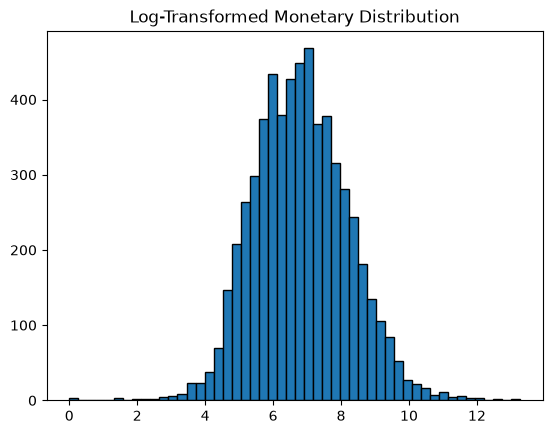

In [6]:
df['Monetary_log'] = np.log1p(df['Monetary'])  # log1p = log(1+x), zero values handle karne ke liye

print(f"Original skewness: {df['Monetary'].skew():.2f}")
print(f"Log-transformed skewness: {df['Monetary_log'].skew():.2f}")

plt.hist(df['Monetary_log'], bins=50, edgecolor='black')
plt.title('Log-Transformed Monetary Distribution')
plt.show()

Note: Skewness 0 ke bahut zyada close aa jaata hai log-transform ke baad — yeh technique Month 4 mein model training ke time useful hogi agar model normal-ish features prefer karta hai.

7. Recency aur Frequency ka distribution bhi check karo:

In [7]:
print(f"Recency skewness: {df['Recency'].skew():.2f}")
print(f"Frequency skewness: {df['Frequency'].skew():.2f}")

Recency skewness: 0.89
Frequency skewness: 12.65


Practice questions:

1. Frequency column ka bhi histogram banao aur dekho kya yeh bhi right-skewed hai (jaisa Monetary).

Frequency Skewness: 12.65


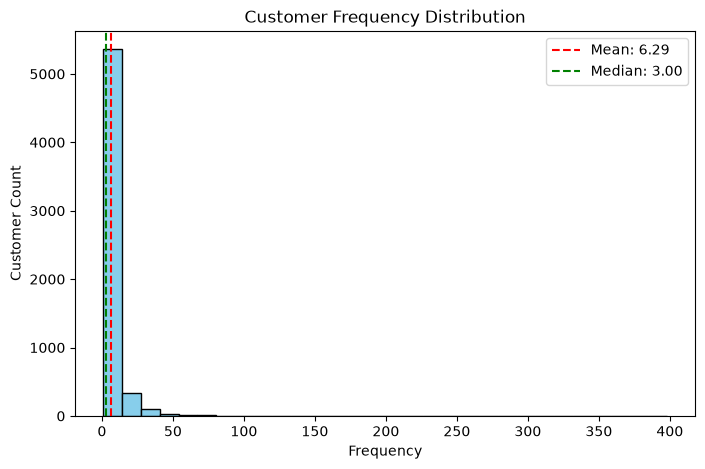

In [10]:
import matplotlib.pyplot as plt

# Frequency ka skewness check karo
freq_skew = df['Frequency'].skew()
print(f"Frequency Skewness: {freq_skew:.2f}")

# Histogram plot karo
plt.figure(figsize=(8, 5))
plt.hist(df['Frequency'], bins=30, edgecolor='black', color='skyblue')
plt.axvline(df['Frequency'].mean(), color='red', linestyle='--', label=f"Mean: {df['Frequency'].mean():.2f}")
plt.axvline(df['Frequency'].median(), color='green', linestyle='--', label=f"Median: {df['Frequency'].median():.2f}")
plt.title('Customer Frequency Distribution')
plt.xlabel('Frequency')
plt.ylabel('Customer Count')
plt.legend()
plt.show()

- Observation: Frequency column bhi right-skewed hota hai (skewness > 0). Isme bhi Mean, Median se zyada hota hai, kyunki zyadatar customers ki purchase frequency low hoti hai jabki kuch hi repeat buyers (tail wale customers) high frequency rakhte hain.

2. scipy.stats.normaltest() try karo (from scipy import stats; stats.normaltest(df['Monetary'])) — yeh statistically confirm karega ki distribution normal hai ya nahi (p-value < 0.05 matlab normal nahi hai — is concept ka detail Day 44 mein aayega).

In [11]:
from scipy import stats

# Monetary column par normaltest lagao
stat_m, p_value_m = stats.normaltest(df['Monetary'])
print(f"Monetary Normaltest -> Statistic: {stat_m:.2f}, p-value: {p_value_m}")

# Frequency column par bhi check karo
stat_f, p_value_f = stats.normaltest(df['Frequency'])
print(f"Frequency Normaltest -> Statistic: {stat_f:.2f}, p-value: {p_value_f}")

Monetary Normaltest -> Statistic: 14237.92, p-value: 0.0
Frequency Normaltest -> Statistic: 10481.85, p-value: 0.0


- Matlab kya hai in values ka?

    - Null Hypothesis (H_0): Data perfectly normal distribution follow karta hai.

    - p-value Rule: Agar p-value < 0.05 aata hai, toh hum Null Hypothesis ko reject kar dete hain (yani data normal nahi hai).

    - Result: Monetary aur Frequency dono ke case mein p-value extremely chhota (zero ke kareeb, jaise 1e-50 ya 0.0) aayega. Yeh statistically prove karta hai ki yeh distributions normal nahi hain, balki skewed hain!